## Bank Customer Churn Prediction & Behavior Analysis

### Dataset: Customer-Churn-Records.csv

In [1]:
# Import essential data science libraries
# NumPy for numerical operations and array handling
import numpy as np
# Pandas for data manipulation and analysis
import pandas as pd
# Matplotlib for creating static visualizations
import matplotlib.pyplot as plt
# Seaborn for statistical data visualization (built on matplotlib)
import seaborn as sns

## Data wrangling or data cleaning 
## Load the data

In [2]:
# Load the data
import pandas as pd

def loading_data(file_name):
    """
    Load a CSV file into a pandas DataFrame.
    
    Parameters:
    -----------
    file_name : str
        Path to the CSV file to be loaded
        
    Returns:
    --------
    pandas.DataFrame or None
        The loaded DataFrame if successful, None otherwise
    
    Notes:
    ------
    This function handles FileNotFoundError exceptions and prints status messages.
    """
    try:
        # Attempt to read the CSV file into a DataFrame
        df = pd.read_csv(file_name)
        # Print success message with the number of rows in the DataFrame
        print(f"File Successfully Loaded. Length of the dataset: {len(df)} rows")
        return df
    except FileNotFoundError as e:
        # Handle case where the file doesn't exist
        print("Error:", e)
    finally:
        # This block always executes, regardless of success or failure
        print("Dataframe operation completed")

In [3]:
### Dataset: 
df = loading_data('Customer-Churn-Records.csv')

File Successfully Loaded. Length of the dataset: 10000 rows
Dataframe operation completed


In [4]:
# Display the first 5 rows of the dataframe to get a quick overview of the data structure
# This helps us understand the columns, data types, and sample values in our dataset
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [5]:
# Display concise summary of the DataFrame including:
# - Total number of entries
# - Column names and their non-null counts
# - Data types for each column
# - Memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

In [6]:
# Statistical Analysis - Generate summary statistics for all numeric columns
# This includes count, mean, std deviation, min, 25%, 50% (median), 75%, and max values
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


## Handle missing valuess.

In [7]:
# Calculate the sum of missing values for each column in the dataframe
missing_value = df.isna().sum()
# Print the count of missing values for each column
print(missing_value)

RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64


In [8]:
# Remove any rows containing missing values (NaN) from the dataframe
# inplace=True modifies the original dataframe instead of creating a copy
df.dropna(inplace = True)
# Check if there are any remaining missing values in each column
# Returns a count of NaN values per column to verify the dropna worked
df.isna().sum()

RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

## Handle Duplicates

In [9]:
# Count the total number of duplicate rows in the dataframe
# df.duplicated() returns a boolean Series where True indicates a duplicate row
# .sum() counts the number of True values (i.e., the number of duplicate rows)
duplicates = df.duplicated().sum()
print(duplicates)

0


In [10]:
# Drop duplicates from the dataframe (note: this doesn't modify df since the result isn't assigned back)
df.drop_duplicates()
# Print the number of duplicate rows that remain in the dataframe
print(df.duplicated().sum())

0


## Handle Inconsistent Data

In [12]:
# Replace zero balances with the mean balance value to handle outliers
df['Balance'] = df['Balance'].replace(0.00,df['Balance'].mean())

# Round the Balance column to whole numbers for simplicity
df['Balance'] = df['Balance'].round(0)

# Convert HasCrCard numeric values to categorical 'Yes'/'No' for better readability
df['HasCrCard'] = df['HasCrCard'].map({0.0:'No',1.0:'Yes'})

# Convert IsActiveMember numeric values to categorical 'Yes'/'No' for better readability
df['IsActiveMember'] = df['IsActiveMember'].map({0.0:'No',1.0:'Yes'})

# Round Age values to whole numbers (removing any decimal places)
df['Age'] = df['Age'].round()

# Convert Complain numeric values to descriptive categories
df['Complain'] = df['Complain'].map({1:'Complained',0:'Not Complained'})

# Convert Exited numeric values to descriptive categories
df['Exited'] = df['Exited'].map({1:'Exited',0:'Not Exited'})

# Display the first 10 rows of the cleaned dataframe
df.head(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,76486.0,1,Yes,Yes,101348.88,Exited,Complained,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83808.0,1,No,Yes,112542.58,Not Exited,Complained,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159661.0,3,Yes,No,113931.57,Exited,Complained,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,76486.0,2,No,No,93826.63,Not Exited,Not Complained,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125511.0,1,Yes,Yes,79084.10,Not Exited,Not Complained,5,GOLD,425
5,6,15574012,Chu,645,Spain,Male,44,8,113756.0,2,Yes,No,149756.71,Exited,Complained,5,DIAMOND,484
6,7,15592531,Bartlett,822,France,Male,50,7,76486.0,2,Yes,Yes,10062.80,Not Exited,Not Complained,2,SILVER,206
7,8,15656148,Obinna,376,Germany,Female,29,4,115047.0,4,Yes,No,119346.88,Exited,Complained,2,DIAMOND,282
8,9,15792365,He,501,France,Male,44,4,142051.0,2,No,Yes,74940.50,Not Exited,Not Complained,3,GOLD,251
9,10,15592389,H?,684,France,Male,27,2,134604.0,1,Yes,Yes,71725.73,Not Exited,Not Complained,3,GOLD,342


## Handling Outliers

In [13]:
# Filter only integer columns
def drop_outliers(df):
    """
    Remove outliers from a dataframe using the IQR method.
    
    This function identifies and removes outliers in numeric columns (int64 and float64)
    based on the Interquartile Range (IQR) method. Values outside 1.5*IQR below Q1 or
    above Q3 are considered outliers and removed.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The input dataframe containing potential outliers
        
    Returns:
    --------
    pandas.DataFrame
        A new dataframe with outliers removed
    """
    # select only int and float columns
    columns = df.select_dtypes(include=['int64','float64']).columns

    # compute bounds for all columns
    bounds = {}
    for column in columns:
        # Calculate quartiles for the current column
        Q1 = df[column].quantile(0.25)  # First quartile (25th percentile)
        Q3 = df[column].quantile(0.75)  # Third quartile (75th percentile)
        IQR = Q3 - Q1  # Interquartile range
        
        # Calculate lower and upper bounds for outlier detection
        # Values outside these bounds will be considered outliers
        lower = Q1 - 1.5 * IQR  # Lower bound
        upper = Q3 + 1.5 * IQR  # Upper bound
        
        # Store bounds for each column
        bounds[column] = (lower, upper)

    # apply filtering once using all bounds
    df_clean = df.copy()  # Create a copy to avoid modifying the original dataframe
    for column in columns:
        lower, upper = bounds[column]  # Get the bounds for the current column
        # Keep only rows where the column value is within bounds
        df_clean = df_clean[(df_clean[column] >= lower) & (df_clean[column] <= upper)]

    return df_clean

In [14]:
# Remove outliers from the dataframe using the drop_outliers function
# This helps improve data quality by eliminating extreme values that could skew analysis
df_clean = drop_outliers(df)

In [15]:
# Function to check for remaining outliers in all numeric columns of a dataframe
def check_outliers_all(df_clean):
    # Select only numeric columns (integer and float types)
    int_columns = df_clean.select_dtypes(include=['int64','float64']).columns
    
    # Iterate through each numeric column
    for col in int_columns:
        # Calculate first quartile (25th percentile)
        Q1 = df_clean[col].quantile(0.25)
        # Calculate third quartile (75th percentile)
        Q3 = df_clean[col].quantile(0.75)
        # Calculate interquartile range (IQR)
        IQR = Q3 - Q1
        
        # Define lower bound for outliers: Q1 - 1.5*IQR
        lower = Q1 - 1.5 * IQR
        # Define upper bound for outliers: Q3 + 1.5*IQR
        upper = Q3 + 1.5 * IQR
        
        # Count how many values fall outside the bounds (outliers)
        count = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)].shape[0]
        
        # Print the column name and number of outliers found
        print(f"{col}: {count} outliers remaining")

In [16]:
# Remove outliers from the dataframe using a custom function
df_clean = drop_outliers(df)

# Verify that outliers have been successfully removed by checking all columns
check_outliers_all(df_clean)

RowNumber: 0 outliers remaining
CustomerId: 0 outliers remaining
CreditScore: 0 outliers remaining
Age: 163 outliers remaining
Tenure: 0 outliers remaining
Balance: 2 outliers remaining
NumOfProducts: 0 outliers remaining
EstimatedSalary: 0 outliers remaining
Satisfaction Score: 0 outliers remaining
Point Earned: 0 outliers remaining


## Feature Engineering

In [18]:
# Define a function to categorize people into age groups
def age_group(age):
    # Ages 25 and below are classified as "Young"
    if age <= 25:
        return "Young"
    # Ages 26-35 are classified as "Early_Adult"
    elif age <= 35:
        return "Early_Adult"
    # Ages 36-45 are classified as "Middle_Age"
    elif age <= 45:
        return "Middle_Age"
    # Ages 46-60 are classified as "Senior"
    elif age <= 60:
        return "Senior"
    # Ages 61 and above are classified as "Elder"
    else:
        return "Elder"

# Apply the age_group function to each value in the 'Age' column
# and create a new column 'Age_Group' with the results
df['Age_Group'] = df['Age'].apply(age_group)
# Display the first 10 entries of the newly created 'Age_Group' column
print(df['Age_Group'].head(10))

0     Middle_Age
1     Middle_Age
2     Middle_Age
3     Middle_Age
4     Middle_Age
5     Middle_Age
6         Senior
7    Early_Adult
8     Middle_Age
9    Early_Adult
Name: Age_Group, dtype: object


In [19]:
# Function to convert numerical satisfaction scores to descriptive categories
def statisfaction_group(score):
    # Map score 1 to "Very Dissatisfied"
    if score == 1:
        return "Very Dissatisfied"
    # Map score 2 to "Dissatisfied"
    elif score == 2:
        return "Dissatisfied"
    # Map score 3 to "Neutral"
    elif score == 3:
        return "Neutral"
    # Map score 4 to "Satisfied"
    elif score == 4:
        return "Satisfied"
    # Map score 5 (or any other value) to "Very Satisfied"
    else:
        return "Very Satisfied"

# Apply the function to create a new column 'Satisfaction_Group' based on 'Satisfaction Score'
df['Satisfaction_Group'] = df['Satisfaction Score'].apply(statisfaction_group)
# Display the first 10 rows of the new categorical column
print(df['Satisfaction_Group'].head(10))

0      Dissatisfied
1           Neutral
2           Neutral
3    Very Satisfied
4    Very Satisfied
5    Very Satisfied
6      Dissatisfied
7      Dissatisfied
8           Neutral
9           Neutral
Name: Satisfaction_Group, dtype: object


In [21]:
# Count the number of customers in each churn category (Exited=1 means churned, Exited=0 means retained)
df['Exited'].value_counts()

Exited
Not Exited    7962
Exited        2038
Name: count, dtype: int64

In [22]:
# Churn rate for each category

# Convert 'Exited' column from categorical to binary (1 for churned customers, 0 for retained customers)
df['Exited'] = df['Exited'].map({'Exited':1,'Not Exited':0})

# Calculate the average churn rate for each geographical region
# This gives us the proportion of customers who left in each country
churn_category = df.groupby('Geography')['Exited'].mean()

# Display the churn rate by geography
churn_category

Geography
France     0.161747
Germany    0.324432
Spain      0.166734
Name: Exited, dtype: float64

In [23]:
# Change the data into New CSV file
# Export the DataFrame 'df' to a CSV file without including the index column
new_csv = df.to_csv('New_Customer_Churned_Data.csv', index=False)

# Print a confirmation message showing the file was created successfully
# and display the number of records in the DataFrame
print(f'Successfully New_Customer_Churned_Data.csv created with {len(df)} datas')

Successfully New_Customer_Churned_Data.csv created with 10000 datas


# Churn Distribution

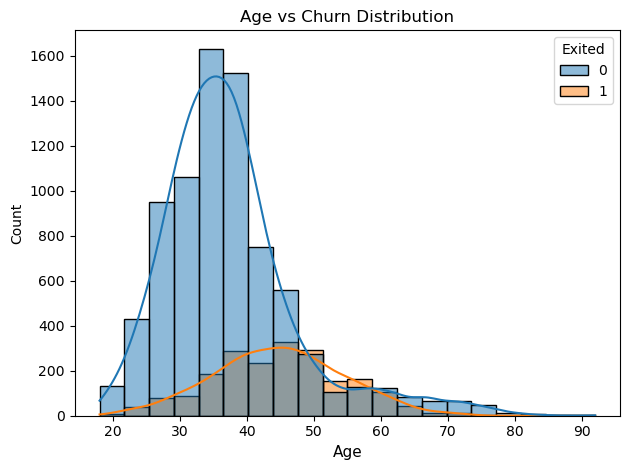

plot saved successfully


In [24]:
# Create a histogram plot showing the distribution of customer ages
# with separate colors for churned vs non-churned customers
sns.histplot(data=df, x='Age', hue='Exited', kde=True, bins=20)

# Add a descriptive title to the plot
plt.title("Age vs Churn Distribution")

# Label the x-axis and set font size
plt.xlabel('Age', fontsize=11)

# Save the figure as a high-resolution PNG file
plt.savefig("Age vs Churn_distribution(plot 1).png", dpi=300, bbox_inches='tight') 

# Adjust the layout to prevent overlapping elements
plt.tight_layout()

# Display the plot
plt.show()

# Confirm successful save with a print statement
print('plot saved successfully')

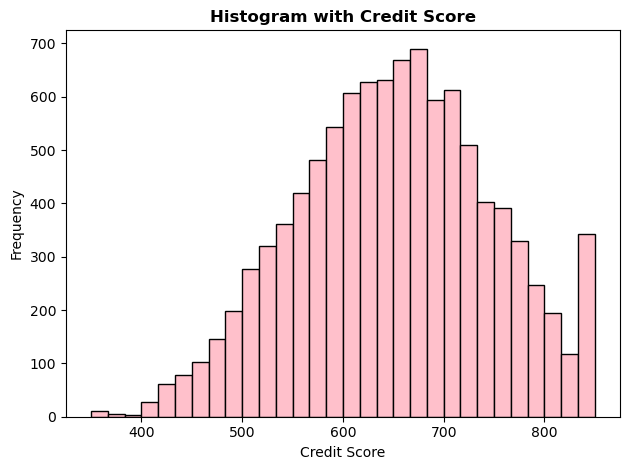

plot saved successfully


In [25]:
# Create a histogram of Credit Scores
plt.hist(df['CreditScore'], bins=30, color='pink', edgecolor='black')  # Plot histogram with 30 bins and pink color
plt.xlabel('Credit Score')  # Label for x-axis
plt.ylabel('Frequency')  # Label for y-axis
plt.title('Histogram with Credit Score',fontsize = 12,fontweight = 'bold')  # Add title with formatting
plt.savefig("Histogram with Credit Score(plot 2).png", dpi=300, bbox_inches='tight')  # Save high-resolution image
plt.tight_layout()  # Adjust padding to ensure everything fits properly
plt.show()  # Display the plot
print('plot saved successfully')  # Confirmation message

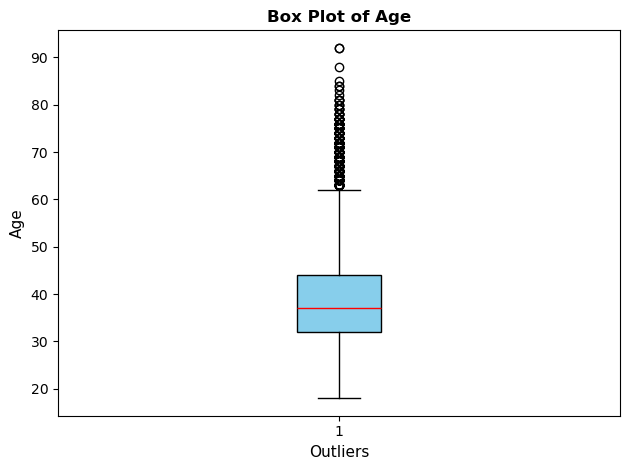

plot saved successfully


In [26]:
# Create a box plot to visualize the distribution and outliers of the Age column
plt.boxplot(df['Age'], vert=True, patch_artist=True,
            boxprops=dict(facecolor='skyblue', color='black'),  # Set box color to skyblue with black border
            medianprops=dict(color='red'))  # Set median line color to red
plt.xlabel('Outliers',fontsize = 11)  # Label for x-axis
plt.ylabel('Age',fontsize = 11)  # Label for y-axis
plt.title('Box Plot of Age',fontweight = 'bold',fontsize = 12)  # Add title with bold font
plt.savefig("Box Plot of Age(plot 3).png", dpi=300, bbox_inches='tight')  # Save figure with high resolution
plt.tight_layout()  # Adjust subplot parameters for better fit
plt.show()  # Display the plot
print('plot saved successfully')  # Confirmation message

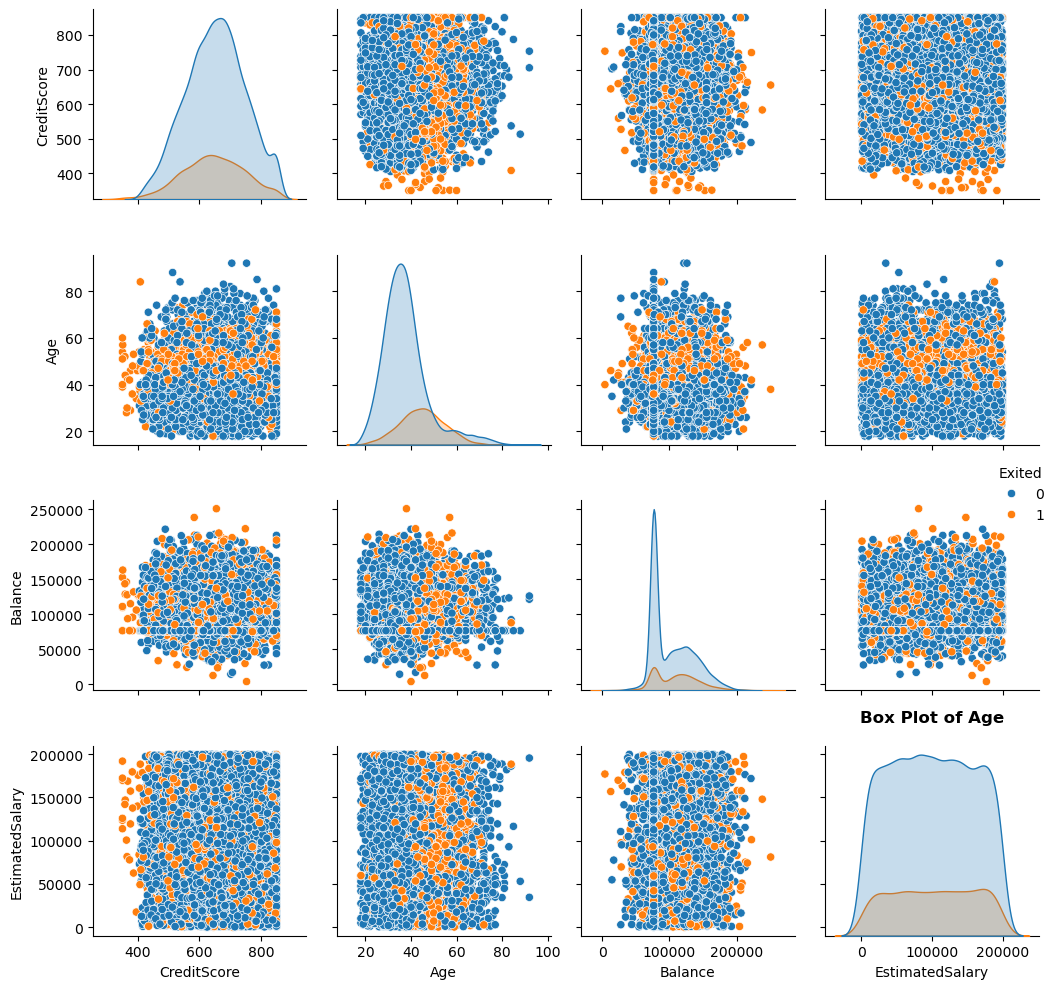

plot saved successfully


In [27]:
# Create a pairplot to visualize relationships between multiple numerical variables
# The hue parameter colors points by the 'Exited' column to show differences between customer groups
sns.pairplot(df[['CreditScore','Age','Balance','EstimatedSalary','Exited']], hue='Exited')

# Add a title to the plot (note: this title doesn't match the actual plot type)
plt.title('Box Plot of Age',fontweight = 'bold',fontsize = 12)

# Save the figure as a PNG file with high resolution (300 dpi)
plt.savefig("Pair plot for mutliple columns (plot 4).png", dpi=300, bbox_inches='tight') 

# Adjust the layout to prevent overlapping elements
plt.tight_layout()

# Display the plot
plt.show()

# Print confirmation message after saving the plot
print('plot saved successfully')

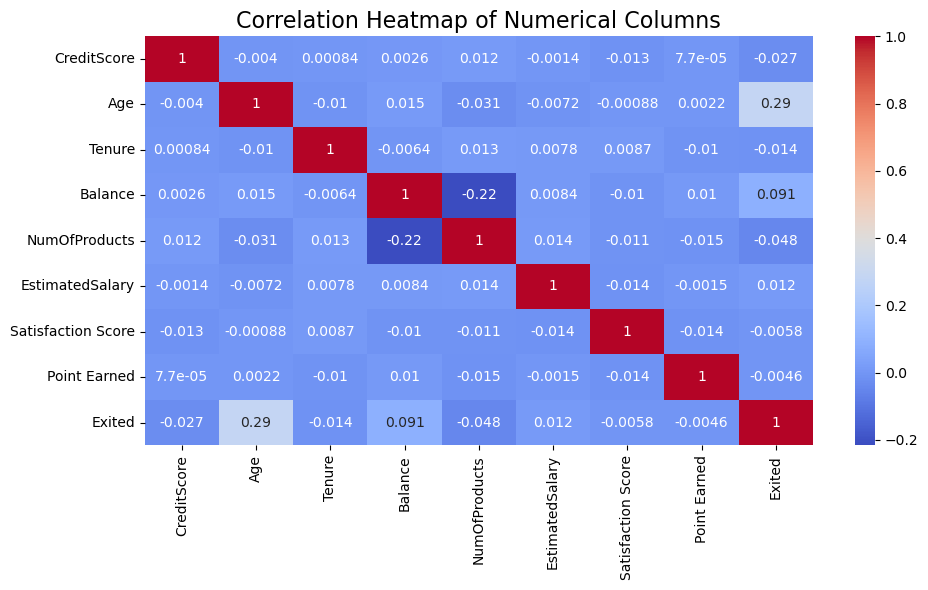

plot saved successfully


In [28]:
# Define numeric columns to include in correlation analysis
numeric_cols = ['CreditScore','Age','Tenure','Balance','NumOfProducts',
                'EstimatedSalary','Satisfaction Score','Point Earned']

# Create a figure with specified size
plt.figure(figsize=(10,6))

# Generate correlation heatmap with annotations and color scheme
sns.heatmap(df[numeric_cols + ['Exited']].corr(), annot=True, cmap='coolwarm')

# Add title to the heatmap with custom font size
plt.title("Correlation Heatmap of Numerical Columns", fontsize=16)

# Save the figure as PNG with high resolution and proper cropping
plt.savefig("Correlation Heatmap of Numerical Columns (plot 5).png", dpi=300, bbox_inches='tight') 

# Adjust layout to prevent overlapping elements
plt.tight_layout()

# Display the plot
plt.show()

# Confirmation message for successful save
print('plot saved successfully')

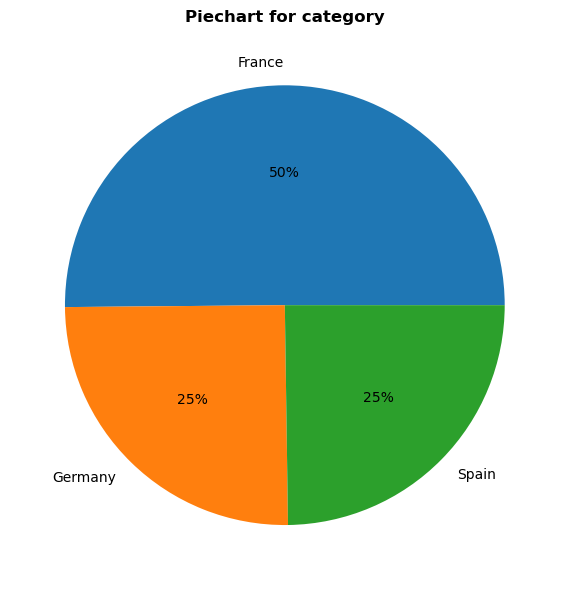

plot saved successfully


In [29]:
# Count the occurrences of each unique value in the 'Geography' column
geo_counts = df['Geography'].value_counts()

# Create a figure with specified size
plt.figure(figsize=(10,6))

# Create a pie chart showing the distribution of Geography values
# autopct adds percentage labels to each slice
plt.pie(geo_counts, labels=geo_counts.index, autopct='%.0f%%')

# Add a title to the pie chart with custom formatting
plt.title('Piechart for category',fontweight = 'bold',fontsize = 12)

# Save the figure to a PNG file with high resolution and tight borders
plt.savefig("Piechart for category (plot 6).png", dpi=300, bbox_inches='tight') 

# Adjust layout to ensure everything fits properly
plt.tight_layout()

# Display the pie chart
plt.show()

# Print confirmation message
print('plot saved successfully')

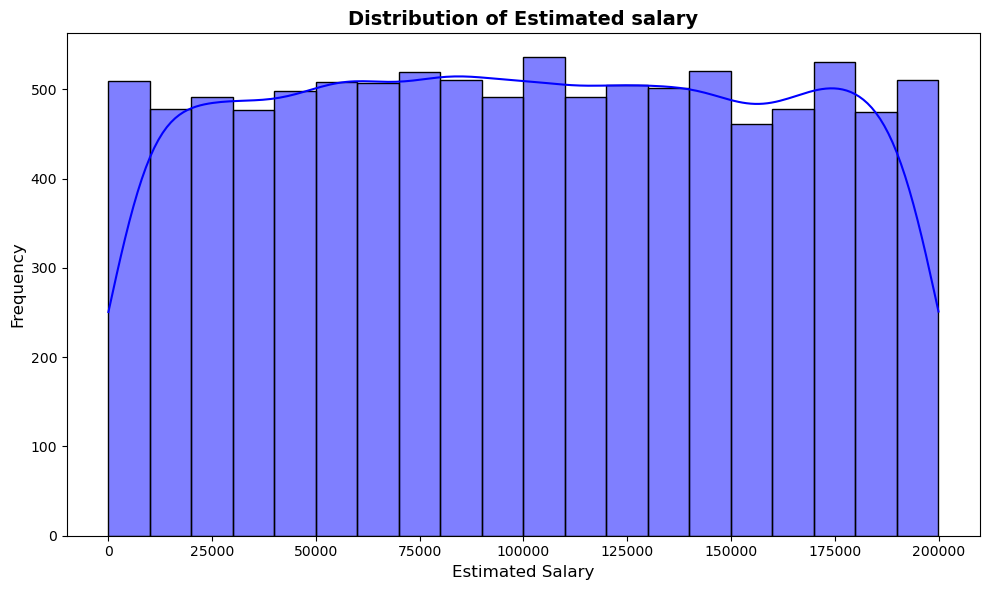

plot saved successfully


In [30]:
# Create a figure with specified size (10x6 inches)
plt.figure(figsize=(10, 6))
# Create a histogram with KDE (Kernel Density Estimate) overlay
# KDE helps visualize the probability density of the data
sns.histplot(data=df, x='EstimatedSalary', kde=True, bins=20, color='blue')    
# Add x-axis label with specified font size
plt.xlabel('Estimated Salary', fontsize=12)
# Add y-axis label with specified font size
plt.ylabel('Frequency', fontsize=12)
# Add title with specified font size and bold weight
plt.title('Distribution of Estimated salary', fontsize=14, fontweight='bold')
# Save the figure as a PNG file with high resolution (300 DPI) and tight borders
plt.savefig("Distribution of Estimated salary (plot 7).png", dpi=300, bbox_inches='tight') 
# Adjust layout to ensure all elements fit properly
plt.tight_layout()
# Display the plot
plt.show()
# Print confirmation message after saving the plot
print('plot saved successfully')

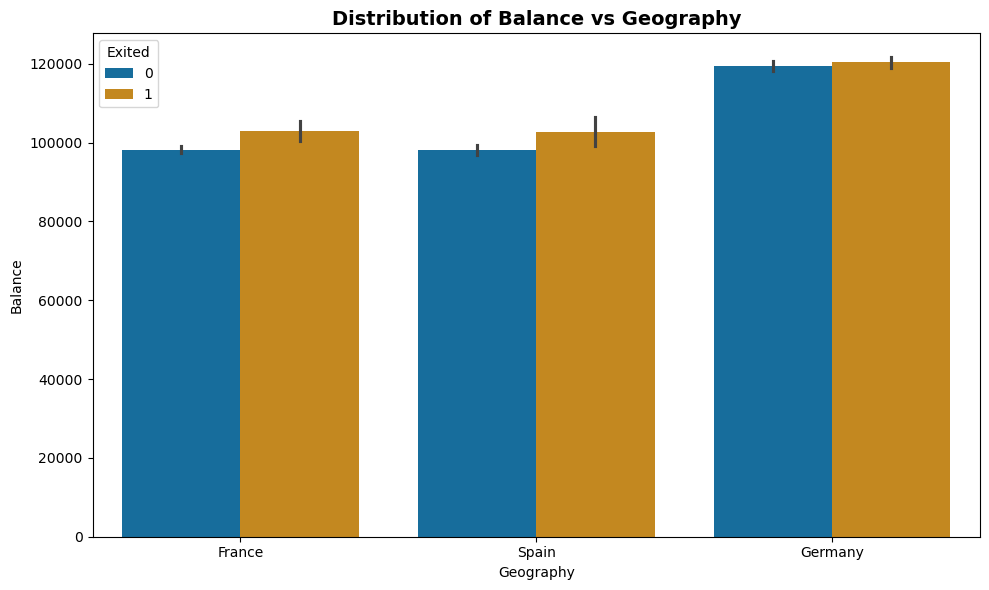

plot saved successfully


<Figure size 640x480 with 0 Axes>

In [31]:
# Create a figure with specified size (10x6 inches)
plt.figure(figsize=(10, 6))

# Create a bar plot showing the relationship between Geography and Balance
# The bars are grouped by the 'Exited' column (customer churn status)
# Using a colorblind-friendly palette for better accessibility
sns.barplot(x='Geography', y='Balance',hue ='Exited', data=df,palette ='colorblind')

# Add a title to the plot with custom font size and weight
plt.title('Distribution of Balance vs Geography', fontsize=14, fontweight='bold')

# Adjust layout to prevent overlapping elements
plt.tight_layout()

# Display the plot
plt.show()

# Save the figure to a PNG file with high resolution (300 DPI)
# bbox_inches='tight' removes extra whitespace around the plot
plt.savefig("Distribution of Balance vs Geography (plot 8).png", dpi=300, bbox_inches='tight')

# Print confirmation message
print('plot saved successfully')

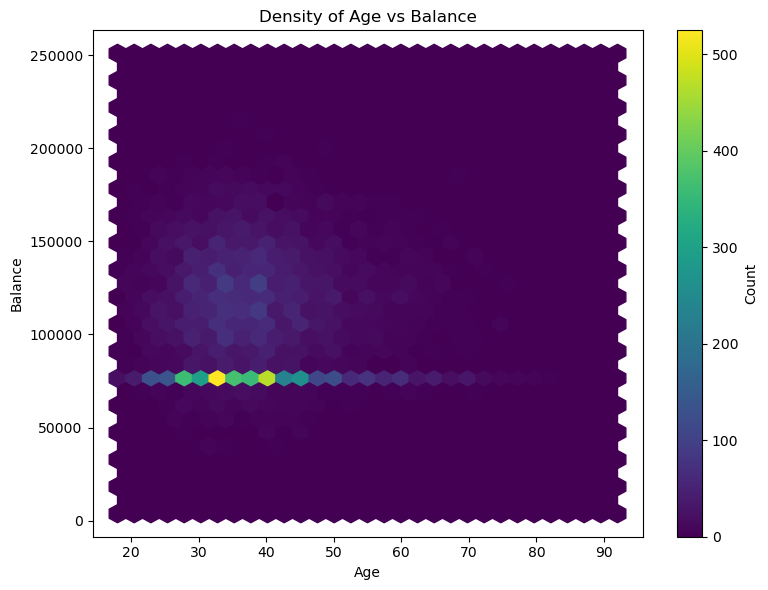

plot saved successfully


<Figure size 640x480 with 0 Axes>

In [32]:
# Create a figure with specified size (8 inches width, 6 inches height)
plt.figure(figsize=(8,6))

# Create a hexbin plot showing the density relationship between Age and Balance
# gridsize=30 determines the number of hexagons in the grid
plt.hexbin(df['Age'], df['Balance'], gridsize=30)
# Add a color bar to indicate count density
plt.colorbar(label='Count')

# Add labels to the x and y axes
plt.xlabel("Age")
plt.ylabel("Balance")
# Add a title to the plot
plt.title("Density of Age vs Balance")
# Adjust layout to ensure everything fits properly
plt.tight_layout()
# Display the plot
plt.show()
# Save the figure to a file with high resolution (300 dpi) and tight borders
plt.savefig("Density of Age vs Balance (plot 9).png", dpi=300, bbox_inches='tight')
# Print confirmation message
print('plot saved successfully')

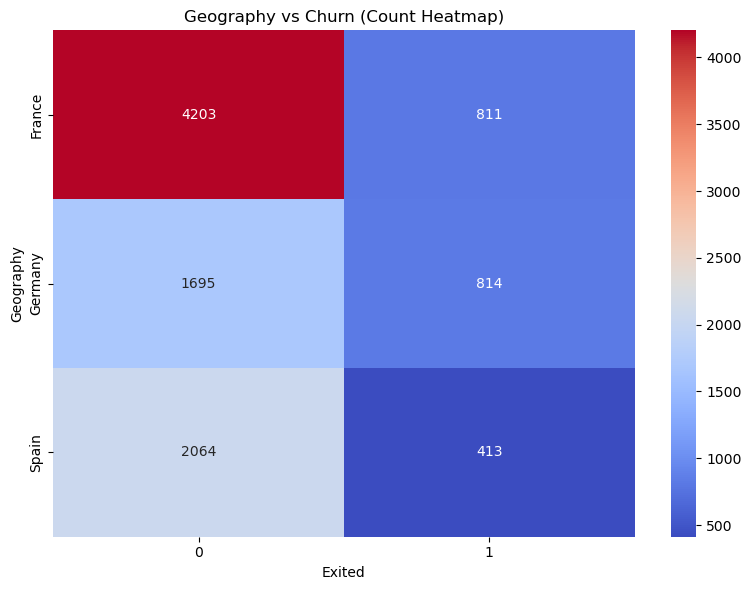

plot saved successfully


<Figure size 640x480 with 0 Axes>

In [33]:
# Create a figure with specified size (8x6 inches)
plt.figure(figsize=(8,6))

# Create a cross-tabulation table between Geography and Exited columns
# This counts how many customers from each geography have exited or not
ct = pd.crosstab(df['Geography'], df['Exited'])

# Create a heatmap visualization of the cross-tabulation
# annot=True: Show the values in each cell
# fmt='d': Format the values as integers
# cmap='coolwarm': Use a blue-red color scheme
sns.heatmap(ct, annot=True, fmt='d', cmap='coolwarm')

# Add a title to the plot
plt.title("Geography vs Churn (Count Heatmap)")

# Adjust layout to ensure everything fits properly
plt.tight_layout()

# Display the plot
plt.show()

# Save the figure to a file with high resolution (300 dpi)
plt.savefig("Geography vs Churn (Count Heatmap)(plot 10).png", dpi=300, bbox_inches='tight')

# Print confirmation message
print('plot saved successfully')